# Optimizing an Artificial Neural Network

There are a number of ways to optimize an ANN when the model is succumbed to either overfitting or underfitting. In case of underfitting, some of the ways to improve the NN include:

* Increasing neurons or layers
* Increasing number of epochs
* Adjust learning rate
* Reducing dropout
* Adding more features
* Experimenting with different architecture

In case of overfitting, some of the ways to improve the NN include:

* Using the entire dataset and/or running it on GPU
* Simplify the NN architecture
* Turning off random neurons (dropout)
* Regularization of the model
* Data augmentation
* Batch normalization in hidden layers
* Early stopping


In this notebook, we optimize the ANN model created previously (https://github.com/swethab2113/Learn-PyTorch/blob/main/5_ANN.ipynb)

## Use entire dataset and perform computations on GPU

If your system does not have GPU, switch to Google Colab which provides it own GPU host (T4). To activate that, go to Runtime > Change runtime type and look for T4 GPU, click okay/save and restart the session.

In [1]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


### Import essentials

In [2]:
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

### Set seed for reproducibility

In [3]:
torch.manual_seed(42)

### Load Fashion MNIST dataset

In [4]:
import kagglehub
import os

path = kagglehub.dataset_download("zalando-research/fashionmnist")
files = os.listdir(path)

print("Path to dataset files:", path)
print("Files: \n", files)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist
Files: 
 ['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [5]:
data = pd.read_csv(os.path.join(path, 'fashion-mnist_train.csv'))
print(f"Total Samples: ", data.shape[0])
data.head()

Total Samples:  60000


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df = data.copy()
print(f"Total Samples in df: ", df.shape[0])
print(f"Number of features: ", df.iloc[0, 1:].shape[0])
print(f"Number of classes in target: ", df['label'].nunique())
df.head()

Total Samples in df:  60000
Number of features:  784
Number of classes in target:  10


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


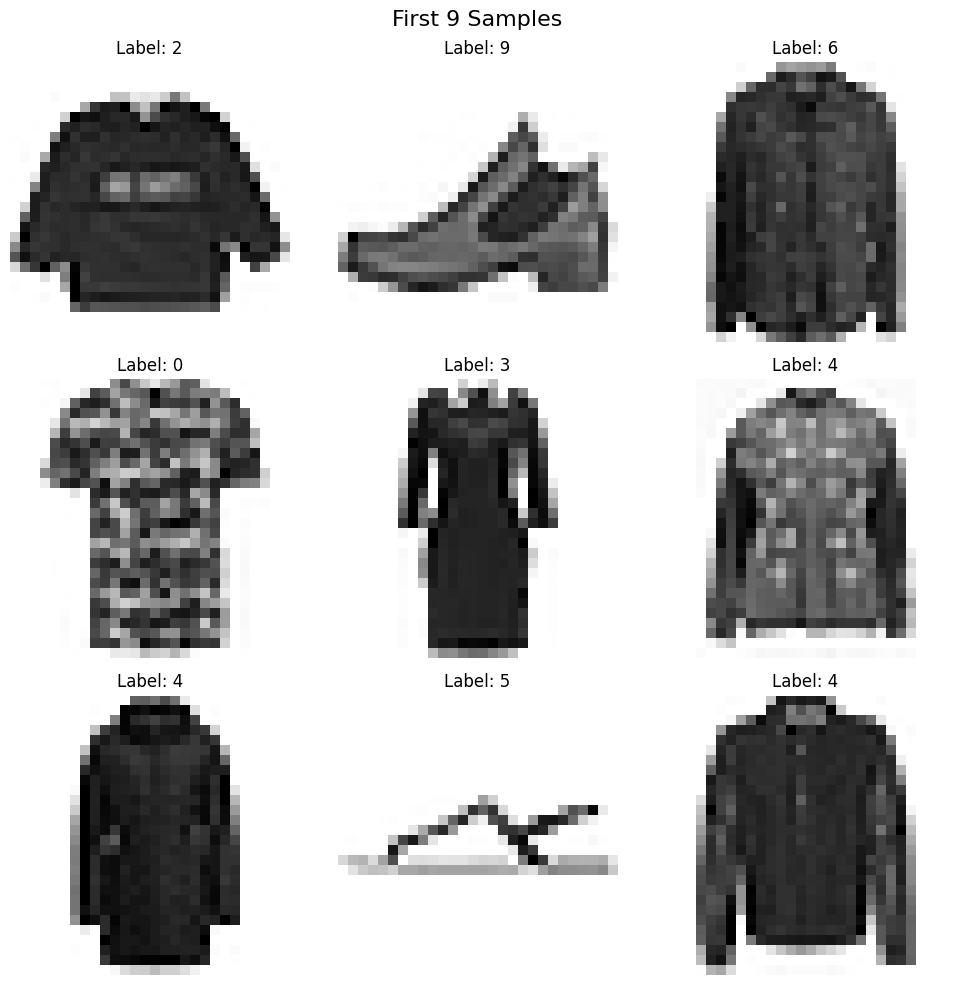

In [7]:
# images represented in pixels in a row are reshaped to 28 x 28 matrix
# the 28 x 28 matrix is then plotted using matplotlib's imshow function

fig, axes = plt.subplots(3, 3, figsize=(10,10))
fig.suptitle("First 9 Samples", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap="binary")
    ax.axis("off")
    ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout()
plt.show()

### Split data into train and test

In [8]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scale features

In [9]:
# pixels range between 0 to 255
X_train = X_train/255.0
X_test = X_test/255.0

### Create CustomDataset class

In [10]:
class CustomDataset(Dataset):
  def __init__(self, features, target):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.target = torch.tensor(target, dtype=torch.long)

  def __len__(self):
    return self.features.shape[0]

  def __getitem__(self, index):
    return self.features[index], self.target[index]

train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

### Create DataLoader

In [11]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True)
# if pin_memory is True, training speed increases on GPU

### Construct neural network model

In [12]:
class ANNModel(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, features):
    out = self.network(features)
    return out

<font color='red'>** **Important Note:** **</font> The softmax activation function is not mentioned explicitly since the cross entropy loss function automatically computes both LogSoftmax and negative log-likelihood loss together in single operation and the model outputs raw unnormalized score called logits.

### Create model instance and move it to GPU

In [13]:
model = ANNModel(X_train.shape[1])

# move model to GPU
model = model.to(device)

loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 100

for epoch in range(epochs):
  loss_update = 0
  for batch_features, batch_target in train_loader:

    # move batch features and batch targets to GPU
    batch_features, batch_target = batch_features.to(device), batch_target.to(device)

    y_pred = model(batch_features)
    loss = loss_func(y_pred, batch_target)
    loss_update += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  epoch_loss = loss_update/len(train_loader)
  print(f"Epoch: {epoch+1}, Loss: {epoch_loss}")

Epoch: 1, Loss: 0.739066051363945
Epoch: 2, Loss: 0.4666919973095258
Epoch: 3, Loss: 0.41287089268366495
Epoch: 4, Loss: 0.38274901994069416
Epoch: 5, Loss: 0.36078107845783236
Epoch: 6, Loss: 0.3445440964003404
Epoch: 7, Loss: 0.3285260680814584
Epoch: 8, Loss: 0.3177949263950189
Epoch: 9, Loss: 0.3064063559571902
Epoch: 10, Loss: 0.2953514814774195
Epoch: 11, Loss: 0.2866288072864215
Epoch: 12, Loss: 0.2789530264337858
Epoch: 13, Loss: 0.27021691321829955
Epoch: 14, Loss: 0.2627734284450611
Epoch: 15, Loss: 0.25750867143273354
Epoch: 16, Loss: 0.24963409835100173
Epoch: 17, Loss: 0.24448148062328498
Epoch: 18, Loss: 0.24028216260671614
Epoch: 19, Loss: 0.2320117489596208
Epoch: 20, Loss: 0.2275569288134575
Epoch: 21, Loss: 0.22254640275239945
Epoch: 22, Loss: 0.21596622436245283
Epoch: 23, Loss: 0.21274130001664163
Epoch: 24, Loss: 0.20793939327200253
Epoch: 25, Loss: 0.20208605768283208
Epoch: 26, Loss: 0.1998334099451701
Epoch: 27, Loss: 0.195743083546559
Epoch: 28, Loss: 0.1899478

### Model evaluation on GPU

In [14]:
model.eval()

ANNModel(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [15]:
# initialize number of samples being evaluated
total_pred = 0

# initialize number of samples with correct prediction
correct_pred = 0

with torch.no_grad():
  for batch_features, batch_target in test_loader:

    # move batch features and batch targets to GPU
    batch_features, batch_target = batch_features.to(device), batch_target.to(device)

    # get predictions
    y_pred_t = model(batch_features)

    # get the maximum probability value and
    # its corresponding label (index of y_pred_t tensor)
    _, predicted = torch.max(y_pred_t, 1)

    # keep count of number of samples being evaluated
    total_pred += batch_target.shape[0]

    # keep count of number of samples with correct prediction
    correct_pred += (predicted == batch_target).sum().item()

  print('Correct predictions: ',correct_pred, '|Total predictions: ', total_pred)
  # compute accuracy across all samples
  print('Accuracy: ', correct_pred/total_pred)

Correct predictions:  10697 |Total predictions:  12000
Accuracy:  0.8914166666666666


### Check for overfitting/underfitting issues

In [16]:
# initialize number of samples being evaluated
total_pred = 0

# initialize number of samples with correct prediction
correct_pred = 0

with torch.no_grad():
  for batch_features, batch_target in train_loader:

    # move batch features and batch targets to GPU
    batch_features, batch_target = batch_features.to(device), batch_target.to(device)

    # get predictions
    y_pred_t = model(batch_features)

    # get the maximum probability value and
    # its corresponding label (index of y_pred_t tensor)
    _, predicted = torch.max(y_pred_t, 1)

    # keep count of number of samples being evaluated
    total_pred += batch_target.shape[0]

    # keep count of number of samples with correct prediction
    correct_pred += (predicted == batch_target).sum().item()

  print('Correct predictions: ',correct_pred, '|Total predictions: ', total_pred)
  # compute accuracy across all samples
  print('Accuracy: ', correct_pred/total_pred)

Correct predictions:  47201 |Total predictions:  48000
Accuracy:  0.9833541666666666


Clearly, the model has overfitting issue since train accuracy is more than test accuracy. We'll do the following options to stabilize our model.

#### Option 1. Dropout

Dropout is a technique where a random number of neurons are turned off during training. This is applied on the hidden layers, right after activation function. Dropout is not applied during evaluation.



```
class ANNModel(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 10)
    )

  def forward(self, features):
    out = self.network(features)
    return out
```



#### Option 2. Batch Normalization

Batch normalization is a technique where activations going into a layer are normalized, making training more stable. This is typically applied to hidden layers by normalizing the output of the preceding layer and its usually followed by an activation function. The mean and variance of the activations within a mini-batch are computed by which the activations are normalized. Doing so, the training process is stabilized and reduces internal covariate shift. Due to the computation of mean and variance over every mini-batch, it adds noise during training process. During evaluation, the running mean and variance computed during training is used instead of using the statistics from the test.



```
class ANNModel(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.network = nn.Sequential(
        
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128)
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Linear(128, 64),
        nn.BatchNorm1d(64)
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 10)
        
    )

  def forward(self, features):
    out = self.network(features)
    return out
```



#### Option 3. Regularization

Regularization is a technique where a penalty term is added to the loss function. There are two types of methods: L1 regularization and L2 regularization.

* L1 regularization adds a penalty term $\lambda \sum |w_{i}|$ to the loss function $L$

<div align='center'>

$L_{modified} = L +\lambda \sum |w_{i}| $

</div>

* L2 regularization adds a penalty term $\lambda \sum |w_{i}|^{2}$ to the loss function $L$

<div align='center'>

$L_{modified} = L + \lambda \sum |w_{i}|^{2}$

</div>

$\lambda$ is a hyperparameter that denotes the strength of regularization. The technique is applied only to the weights of the model to penalize large values and encourage smaller, more generalizable weights. Hence weights decay over time because of the below modification in the weight update formula:

<div align='center'>

$w_{new} = w_{old} - \alpha (\nabla L + \lambda w_{old})$

</div>

Regularization affects weight updates only during training and it does not explicitly influence the model during evaluation.



```
model = ANNModel(X_train.shape[1])

# move model to GPU
model = model.to(device)

loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)
# weight_decay parameter takes \lambda value
```



## Run the modified model

In [17]:
class ANNModel(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.network = nn.Sequential(

        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 10)

    )

  def forward(self, features):
    out = self.network(features)
    return out

In [18]:
model = ANNModel(X_train.shape[1])

# move model to GPU
model = model.to(device)

loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

epochs = 100

for epoch in range(epochs):
  loss_update = 0
  for batch_features, batch_target in train_loader:

    # move batch features and batch targets to GPU
    batch_features, batch_target = batch_features.to(device), batch_target.to(device)

    y_pred = model(batch_features)
    loss = loss_func(y_pred, batch_target)
    loss_update += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  epoch_loss = loss_update/len(train_loader)
  print(f"Epoch: {epoch+1}, Loss: {epoch_loss}")

Epoch: 1, Loss: 0.5737435354193051
Epoch: 2, Loss: 0.4357718807061513
Epoch: 3, Loss: 0.4015389439264933
Epoch: 4, Loss: 0.37968962689240776
Epoch: 5, Loss: 0.36114753832419716
Epoch: 6, Loss: 0.34540819118420285
Epoch: 7, Loss: 0.3346673182845116
Epoch: 8, Loss: 0.32402262845635416
Epoch: 9, Loss: 0.3184669242401918
Epoch: 10, Loss: 0.30751836322744686
Epoch: 11, Loss: 0.30218496949474016
Epoch: 12, Loss: 0.2940441708465417
Epoch: 13, Loss: 0.28834394890069964
Epoch: 14, Loss: 0.28301398079593976
Epoch: 15, Loss: 0.27937964178125063
Epoch: 16, Loss: 0.2716804506580035
Epoch: 17, Loss: 0.2655924047231674
Epoch: 18, Loss: 0.26362562469641365
Epoch: 19, Loss: 0.26059325620532037
Epoch: 20, Loss: 0.2580347033888102
Epoch: 21, Loss: 0.25269554592172305
Epoch: 22, Loss: 0.24683469890554746
Epoch: 23, Loss: 0.2459639302690824
Epoch: 24, Loss: 0.24468814120690027
Epoch: 25, Loss: 0.2368623350262642
Epoch: 26, Loss: 0.23481167927384378
Epoch: 27, Loss: 0.23538957970341046
Epoch: 28, Loss: 0.23

In [19]:
model.eval()

ANNModel(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [20]:
# initialize number of samples being evaluated
total_pred = 0

# initialize number of samples with correct prediction
correct_pred = 0

with torch.no_grad():
  for batch_features, batch_target in test_loader:

    # move batch features and batch targets to GPU
    batch_features, batch_target = batch_features.to(device), batch_target.to(device)

    # get predictions
    y_pred_t = model(batch_features)

    # get the maximum probability value and
    # its corresponding label (index of y_pred_t tensor)
    _, predicted = torch.max(y_pred_t, 1)

    # keep count of number of samples being evaluated
    total_pred += batch_target.shape[0]

    # keep count of number of samples with correct prediction
    correct_pred += (predicted == batch_target).sum().item()

  print('Correct predictions: ',correct_pred, '|Total predictions: ', total_pred)
  # compute accuracy across all samples
  print('Accuracy: ', correct_pred/total_pred)

Correct predictions:  10631 |Total predictions:  12000
Accuracy:  0.8859166666666667


In [21]:
# initialize number of samples being evaluated
total_pred = 0

# initialize number of samples with correct prediction
correct_pred = 0

with torch.no_grad():
  for batch_features, batch_target in train_loader:

    # move batch features and batch targets to GPU
    batch_features, batch_target = batch_features.to(device), batch_target.to(device)

    # get predictions
    y_pred_t = model(batch_features)

    # get the maximum probability value and
    # its corresponding label (index of y_pred_t tensor)
    _, predicted = torch.max(y_pred_t, 1)

    # keep count of number of samples being evaluated
    total_pred += batch_target.shape[0]

    # keep count of number of samples with correct prediction
    correct_pred += (predicted == batch_target).sum().item()

  print('Correct predictions: ',correct_pred, '|Total predictions: ', total_pred)
  # compute accuracy across all samples
  print('Accuracy: ', correct_pred/total_pred)

Correct predictions:  46012 |Total predictions:  48000
Accuracy:  0.9585833333333333


Model Accuracy before optimizing:
* Train score: 0.983
* Test score: 0.891
* Difference: 0.092

Model accuracy after optimizing:
* Train score: 0.958
* Test score: 0.885
* Difference: 0.069

Experimenting with the hyperparameters will help bridge the gap between train and test score.